# Step 12 — Patient Risk Trajectories and Early-Warning Visualization

This analysis demonstrates how an explainable machine-learning model could be
used to visualize changes in estimated deterioration risk during the early ICU
period.

The trajectories are proof-of-concept visualizations derived from the
MIMIC-IV Demo dataset and should not be interpreted as clinically validated
risk estimates.

Feature dataset: (99, 46)
Prediction dataset: (297, 6)
ICU stays: 99
Patients: 79
Positive outcomes: 18

Models:
model
Logistic Regression    99
Random Forest          99
XGBoost                99
Name: count, dtype: int64
XGBoost predictions: 99
Unique ICU stays: 99
Unique patients: 79


,model,fold,index,actual,predicted_probability,predicted_class,subject_id,stay_id
0,XGBoost,1,0,0,0.041353,0,10018328,31269608
1,XGBoost,1,1,0,0.026413,0,10020187,37509585
2,XGBoost,1,2,0,0.043893,0,10020187,32554129
3,XGBoost,1,3,0,0.023392,0,10012853,31338022
4,XGBoost,1,4,0,0.035380,0,10020740,32145159


['model', 'fold', 'index', 'actual', 'predicted_probability', 'predicted_class', 'subject_id', 'stay_id']
Detected probability column: predicted_probability


,subject_id,hadm_id,stay_id,deterioration,predicted_class,risk_probability,risk_percent
55,10021118,24490144,36558922,1,1,0.765793,76.579297
43,10015931,28157142,39544395,0,1,0.765793,76.579297
45,10019777,27738145,34578020,1,1,0.765793,76.579297
54,10004422,21255400,32155744,1,1,0.765793,76.579297
59,10037928,24656677,39804682,0,1,0.765793,76.579297
94,10023771,20044587,33177122,1,1,0.704074,70.407367
93,10011398,27505812,37648963,0,1,0.704074,70.407367
91,10022017,22342963,39497668,1,1,0.704074,70.407367
95,10037861,24540843,34531557,1,1,0.704074,70.407367
37,10015272,27993466,37267577,0,1,0.701804,70.180374


,count,mean,median,min,max
deterioration,,,,,
0,81,0.086,0.035,0.018,0.766
1,18,0.636,0.701,0.047,0.766


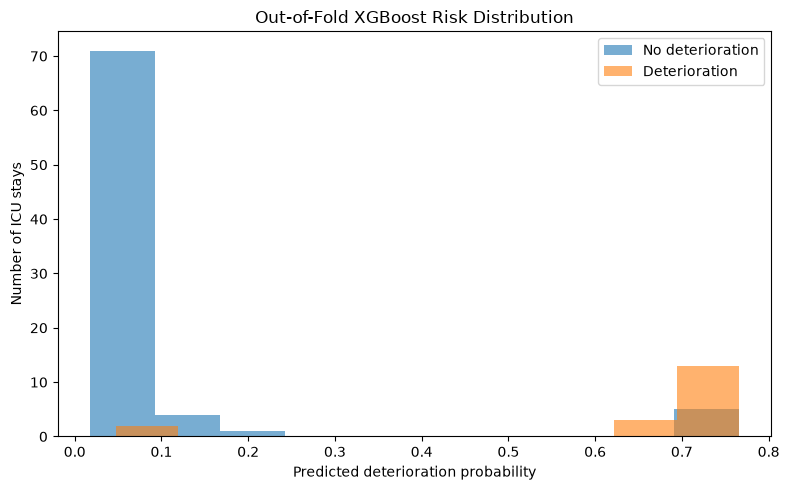

,stay_id,deterioration,risk_percent
55,36558922,1,76.6
43,39544395,0,76.6
45,34578020,1,76.6
54,32155744,1,76.6
59,39804682,0,76.6
94,33177122,1,70.4
93,37648963,0,70.4
91,39497668,1,70.4
95,34531557,1,70.4
37,37267577,0,70.2


,subject_id,hadm_id,stay_id,deterioration,predicted_class,risk_probability,risk_percent
55,10021118,24490144,36558922,1,1,0.765793,76.579297
45,10019777,27738145,34578020,1,1,0.765793,76.579297
54,10004422,21255400,32155744,1,1,0.765793,76.579297
94,10023771,20044587,33177122,1,1,0.704074,70.407367
91,10022017,22342963,39497668,1,1,0.704074,70.407367


,subject_id,hadm_id,stay_id,deterioration,predicted_class,risk_probability,risk_percent
27,10026255,22059910,38229329,1,0,0.050171,5.017053
98,10032725,20611640,30101877,1,0,0.047143,4.714278


,subject_id,hadm_id,stay_id,deterioration,predicted_class,risk_probability,risk_percent
43,10015931,28157142,39544395,0,1,0.765793,76.579297
59,10037928,24656677,39804682,0,1,0.765793,76.579297
93,10011398,27505812,37648963,0,1,0.704074,70.407367
37,10015272,27993466,37267577,0,1,0.701804,70.180374
20,10023239,21759936,35024147,0,1,0.701151,70.115072


,subject_id,hadm_id,stay_id,deterioration,predicted_class,risk_probability,risk_percent
77,10006580,24159665,38329661,0,0,0.017692,1.769170
70,10022041,28909879,30913302,0,0,0.017990,1.798978
79,10022281,29642388,30585761,0,0,0.020481,2.048101
87,10021487,27660781,35065627,0,0,0.020934,2.093399
88,10025612,23403708,32587226,0,0,0.021432,2.143244


,stay_id,case_type,deterioration,risk_probability
55,36558922,True Positive,1,0.765793
27,38229329,False Negative,1,0.050171
43,39544395,False Positive,0,0.765793
77,38329661,True Negative,0,0.017692


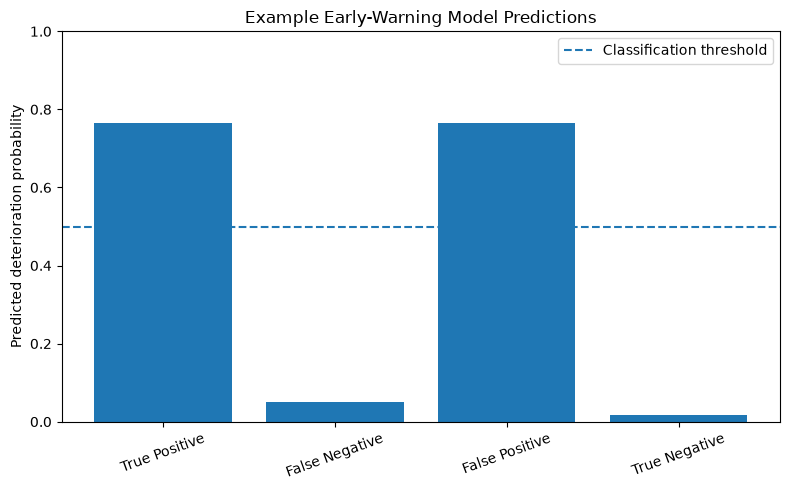

Step 12 tables saved.
STEP 12 — EARLY-WARNING RISK VISUALIZATION COMPLETE
ICU stays: 99
Patients: 79
Deterioration cases: 18
Non-deterioration cases: 81

Mean predicted risk — deterioration: 0.636
Mean predicted risk — no deterioration: 0.086

Example cases:


,stay_id,case_type,risk_probability
55,36558922,True Positive,0.765793
27,38229329,False Negative,0.050171
43,39544395,False Positive,0.765793
77,38329661,True Negative,0.017692



Out-of-fold predictions used.
Risk estimates are proof-of-concept and not clinically validated.
True longitudinal risk trajectories have not yet been generated.


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = Path("../results/model_features_2h.csv")
PRED_PATH = Path("../results/grouped_cv_predictions.csv")

df = pd.read_csv(DATA_PATH)
pred = pd.read_csv(PRED_PATH)

print("Feature dataset:", df.shape)
print("Prediction dataset:", pred.shape)

print("ICU stays:", len(df))
print("Patients:", df["subject_id"].nunique())
print("Positive outcomes:", df["future_deterioration"].sum())

print("\nModels:")
print(pred["model"].value_counts())

xgb_pred = pred[
    pred["model"] == "XGBoost"
].copy()

print("XGBoost predictions:", len(xgb_pred))
# Map each prediction's original feature-row index to its identifiers.
id_lookup = df.loc[:, ["subject_id", "stay_id"]].copy()
id_lookup.insert(0, "index", df.index)

if not xgb_pred["index"].isin(id_lookup["index"]).all():
    raise ValueError("Some prediction indices do not match feature rows.")

# Remove identifiers if this cell is re-executed.
xgb_pred = xgb_pred.drop(
    columns=["subject_id", "stay_id"],
    errors="ignore"
)

xgb_pred = xgb_pred.merge(
    id_lookup,
    on="index",
    how="left",
    validate="many_to_one"
)

print("Unique ICU stays:", xgb_pred["stay_id"].nunique())
print("Unique patients:", xgb_pred["subject_id"].nunique())

display(xgb_pred.head())

print(xgb_pred.columns.tolist())

possible_probability_columns = [
    "predicted_probability",
    "probability",
    "pred_proba",
    "risk_probability",
    "y_prob"
]

PROB_COL = next(
    (
        col for col in possible_probability_columns
        if col in xgb_pred.columns
    ),
    None
)

print("Detected probability column:", PROB_COL)

hadm_lookup = df.loc[:, ["hadm_id"]].copy()
hadm_lookup.insert(0, "index", df.index)

risk_table = xgb_pred.merge(
    hadm_lookup,
    on="index",
    how="left",
    validate="many_to_one"
).copy()
# Rebuild the lookup safely on every execution.
hadm_lookup = pd.DataFrame({
    "index": df.index,
    "hadm_id": df["hadm_id"].to_numpy()
})

if PROB_COL is None:
    raise ValueError("No probability column was detected.")

risk_table = xgb_pred.merge(
    hadm_lookup,
    on="index",
    how="left",
    validate="many_to_one"
)[
    [
        "subject_id",
        "hadm_id",
        "stay_id",
        "actual",
        "predicted_class",
        PROB_COL
    ]
].copy()

risk_table = risk_table.rename(
    columns={
        "actual": "deterioration",
        PROB_COL: "risk_probability"
    }
)

risk_table["risk_percent"] = (
    risk_table["risk_probability"] * 100
)

risk_table = risk_table.sort_values(
    "risk_probability",
    ascending=False
)

display(risk_table.head(15))

risk_by_outcome = (
    risk_table
    .groupby("deterioration")["risk_probability"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
)

display(
    risk_by_outcome.round(3)
)

negative_risk = risk_table.loc[
    risk_table["deterioration"] == 0,
    "risk_probability"
]

positive_risk = risk_table.loc[
    risk_table["deterioration"] == 1,
    "risk_probability"
]

plt.figure(figsize=(8, 5))

plt.hist(
    negative_risk,
    bins=10,
    alpha=0.6,
    label="No deterioration"
)

plt.hist(
    positive_risk,
    bins=10,
    alpha=0.6,
    label="Deterioration"
)

plt.xlabel("Predicted deterioration probability")
plt.ylabel("Number of ICU stays")
plt.title(
    "Out-of-Fold XGBoost Risk Distribution"
)

plt.legend()
plt.tight_layout()
plt.show()

display_table = risk_table[
    [
        "stay_id",
        "deterioration",
        "risk_percent"
    ]
].copy()

display_table["risk_percent"] = (
    display_table["risk_percent"]
    .round(1)
)

display(
    display_table.head(15)
)

true_positives = risk_table[
    (risk_table["deterioration"] == 1) &
    (risk_table["predicted_class"] == 1)
]

display(
    true_positives.head(5)
)

false_negatives = risk_table[
    (risk_table["deterioration"] == 1) &
    (risk_table["predicted_class"] == 0)
]

display(
    false_negatives
)

false_positives = risk_table[
    (risk_table["deterioration"] == 0) &
    (risk_table["predicted_class"] == 1)
]

display(
    false_positives.head(5)
)

true_negatives = risk_table[
    (risk_table["deterioration"] == 0) &
    (risk_table["predicted_class"] == 0)
]

display(
    true_negatives.sort_values(
        "risk_probability"
    ).head(5)
)

examples = pd.concat([
    true_positives.head(1).assign(
        case_type="True Positive"
    ),

    false_negatives.head(1).assign(
        case_type="False Negative"
    ),

    false_positives.head(1).assign(
        case_type="False Positive"
    ),

    true_negatives.sort_values(
        "risk_probability"
    ).head(1).assign(
        case_type="True Negative"
    )
])

display(
    examples[
        [
            "stay_id",
            "case_type",
            "deterioration",
            "risk_probability"
        ]
    ]
)

plt.figure(figsize=(8, 5))

plt.bar(
    examples["case_type"],
    examples["risk_probability"]
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Classification threshold"
)

plt.ylim(0, 1)

plt.ylabel(
    "Predicted deterioration probability"
)

plt.title(
    "Example Early-Warning Model Predictions"
)

plt.xticks(rotation=20)

plt.legend()

plt.tight_layout()
plt.show()

RESULTS_DIR = Path("../results")
FIGURE_DIR = Path("../figures")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

risk_table.to_csv(
    RESULTS_DIR / "xgboost_oof_risk_table.csv",
    index=False
)

examples.to_csv(
    RESULTS_DIR / "example_model_cases.csv",
    index=False
)

print("Step 12 tables saved.")


print("=" * 60)
print("STEP 12 — EARLY-WARNING RISK VISUALIZATION COMPLETE")
print("=" * 60)

print("ICU stays:", len(risk_table))
print(
    "Patients:",
    risk_table["subject_id"].nunique()
)

print(
    "Deterioration cases:",
    risk_table["deterioration"].sum()
)

print(
    "Non-deterioration cases:",
    (risk_table["deterioration"] == 0).sum()
)

print(
    "\nMean predicted risk — deterioration:",
    round(
        risk_table.loc[
            risk_table["deterioration"] == 1,
            "risk_probability"
        ].mean(),
        3
    )
)

print(
    "Mean predicted risk — no deterioration:",
    round(
        risk_table.loc[
            risk_table["deterioration"] == 0,
            "risk_probability"
        ].mean(),
        3
    )
)

print("\nExample cases:")
display(
    examples[
        [
            "stay_id",
            "case_type",
            "risk_probability"
        ]
    ]
)

print(
    "\nOut-of-fold predictions used."
)

print(
    "Risk estimates are proof-of-concept and not clinically validated."
)

print(
    "True longitudinal risk trajectories have not yet been generated."
)